# RoomBeacon — Rental Price Benchmark V3: Methodology-Hardened

This benchmark predicts `price_model_value` from canonical Silver. Model/feature/transform/tuning choices use **development chronological folds only**. The final chronological TEST is sealed until one candidate is locked. No Bronze/Silver logic is changed.

## 01 Runtime, canonical input, and reproducibility

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json, platform, sys, time
PROJECT_ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'crawler').is_dir() and (p/'analytics').is_dir())
sys.path.insert(0,str(PROJECT_ROOT))
import duckdb,numpy as np,pandas as pd,matplotlib.pyplot as plt
import sklearn,xgboost,lightgbm,catboost
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from IPython.display import display,Markdown
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor,RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet,LinearRegression,Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.tree import DecisionTreeRegressor
from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.modeling_benchmark import *
from notebooks.utils.modeling_benchmark import prepare_lightgbm_categories
from notebooks.utils.shadow_validation import build_reference_profile,file_sha256,persist_champion_artifact
from notebooks.utils.listing_semantics import BUSINESS_TARGET_DEFINITION,semantic_model_eligibility
SEED=42; np.random.seed(SEED); plt.style.use('seaborn-v0_8-whitegrid')
SILVER_PATH=resolve_runtime_path(env.processing.silver_dir)/'rental_listings.parquet'
METADATA_PATH=resolve_runtime_path(env.processing.silver_dir)/'rental_listings.metadata.json'
with duckdb.connect(':memory:') as con: silver_df=con.execute('select * from read_parquet(?)',[str(SILVER_PATH)]).df()
silver_metadata=json.loads(METADATA_PATH.read_text())
assert len(silver_df)==silver_df.rental_post_id.nunique()==silver_metadata['row_count']
versions={'Python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,'scikit-learn':sklearn.__version__,'xgboost':xgboost.__version__,'lightgbm':lightgbm.__version__,'catboost':catboost.__version__}
display(pd.Series(versions,name='Version').to_frame())

,Version
Python,3.12.3
pandas,3.0.6
numpy,2.5.3
scikit-learn,1.9.1
xgboost,3.0.5
lightgbm,4.7.0
catboost,1.2.8


## 02 Business target, semantic population, and leakage contract

**Business target:** Predict the asking rental price for an ordinary individual rental listing/unit represented by RoomBeacon.

SALE, TRANSFER, WHOLE_BUILDING, and MULTI_UNIT_BUSINESS evidence is incompatible. UNKNOWN is retained when no conflicting evidence exists; sparse text is not guessed. Semantic labels are eligibility/audit fields and are not predictors.

,Policy
Business target,Predict the asking rental price for an ordinar...
UNKNOWN policy,PERMISSIVE by default; STRICT evaluated separa...
Accepted numeric trust statuses,"TRUSTED_EXISTING, TRUSTED_REPARSED"


,Stage,Rows,Removed / reviewed,Percent of Silver,Policy
0,Silver rows,132436,0,100.000000,PERMISSIVE
1,Numeric target candidate,128051,4385,96.688967,PERMISSIVE
2,Lineage trusted,118886,9165,89.768643,PERMISSIVE
3,Semantic target supported,114436,4450,86.408529,PERMISSIVE
4,Area supported,112226,2210,84.739799,PERMISSIVE
5,Rental-compatible,112226,0,84.739799,PERMISSIVE
6,Final model eligible,112226,0,84.739799,PERMISSIVE


,Stage,Rows,Removed / reviewed,Percent of Silver,Policy
0,Silver rows,132436,0,100.000000,STRICT
1,Numeric target candidate,128051,4385,96.688967,STRICT
2,Lineage trusted,118886,9165,89.768643,STRICT
3,Semantic target supported,114436,4450,86.408529,STRICT
4,Area supported,112226,2210,84.739799,STRICT
5,Rental-compatible,79323,32903,59.895346,STRICT
6,Final model eligible,79323,0,59.895346,STRICT


,Rows
listing_intent,
RENT,92021
UNKNOWN,39525
TRANSFER,866
SALE,24


,Rows
rental_scope,
SINGLE_OR_ORDINARY_UNIT,92789
UNKNOWN,39442
MULTI_UNIT_BUSINESS,202
WHOLE_BUILDING,3


...

,rental_post_id,source_code,title_clean,price_amount_clean,price_model_value,price_target_model_value,price_target_trust_status,price_target_trust_reason,listing_intent,rental_scope,model_exclusion_reason
3,53601,mogi,Phòng Trọ Giá Rẻ 30m2 - Full Nội Thất + Ban Cô...,3000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,RENT,SINGLE_OR_ORDINARY_UNIT,NUMERIC_TARGET_NOT_TRUSTED
4,53602,mogi,PHÒNG TRỌ GIÁ RẺ Mới 100% - Full Nội Thất - Ba...,3000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,RENT,SINGLE_OR_ORDINARY_UNIT,NUMERIC_TARGET_NOT_TRUSTED
5,53603,mogi,Phòng Trọ Mới Giá Rẻ - Full Nội Thất + Ban Côn...,3000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,RENT,SINGLE_OR_ORDINARY_UNIT,NUMERIC_TARGET_NOT_TRUSTED
6,53604,mogi,Phòng Trọ Giá Rẻ - Full Nội Thất & Ban Công - ...,3000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,RENT,SINGLE_OR_ORDINARY_UNIT,NUMERIC_TARGET_NOT_TRUSTED
10,53608,mogi,PHÒNG CAO CẤP GIÁ RẺ - Full Nội Thất Mới - Nga...,4000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,UNKNOWN,UNKNOWN,NUMERIC_TARGET_NOT_TRUSTED
27,53625,mogi,Ktx Livi House Quận 5 - 10 - Phú Nhuận giá rẻ ...,1000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,UNKNOWN,UNKNOWN,NUMERIC_TARGET_NOT_TRUSTED
31,53629,mogi,"KTX q10, 5, PN: 1.300K - 1.700K/tháng (Bao trọ...",1000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,UNKNOWN,UNKNOWN,NUMERIC_TARGET_NOT_TRUSTED
33,53631,mogi,Giải pháp lưu trú tối ưu cho các bạn sinh viên...,1000000.0,NaN,NaN,PARSER_DISAGREEMENT_REVIEW,EXISTING_AND_REPARSED_PRICE_DISAGREE,UNKNOWN,UNKNOWN,NUMERIC_TARGET_NOT_TRUSTED
41,53639,chothuenha,"CHO THUÊ PHÒNG TRỌ - Khu vực nhà ở quân đội, a...",6500000.0,6500000.0,6500000.0,TRUSTED_EXISTING,ALIGNED_RAW_PRICE_MATCH,RENT,SINGLE_OR_ORDINARY_UNIT,AREA_NOT_SUPPORTED
55,53653,chothuenha,"Cho thuê phòng trọ 2,5 triệu - Diện tích 16m2 ...",2500000.0,2500000.0,2500000.0,TRUSTED_EXISTING,EXPLICIT_TITLE_PRICE_MATCHES_CLEAN_VALUE,RENT,SINGLE_OR_ORDINARY_UNIT,AREA_NOT_SUPPORTED


### Valid high-price rows retained by canonical trust evidence

,rental_post_id,source_code,title_clean,price_model_value,area_value_clean,listing_intent,rental_scope
114907,255337,nhatot,Mô tả chi tiết,170000000.0,189.0,UNKNOWN,UNKNOWN
9692,68016,mogi,"Cho thuê gấp Panorama, Phú Mỹ Hưng, Quận 7",60000000.0,142.0,RENT,SINGLE_OR_ORDINARY_UNIT
113333,251674,phongtro123,"SANG HĐ NHÀ CHO THUÊ 13 CĂN HỘ ĐẶNG VĂN NGỮ, P...",50000000.0,400.0,RENT,SINGLE_OR_ORDINARY_UNIT
11945,70708,mogi,"Cần cho thuê nguyên căn nhà phố Hưng Gia, Hưng...",45000000.0,111.0,RENT,SINGLE_OR_ORDINARY_UNIT
11947,70710,mogi,"Cần cho thuê nguyên căn nhà phố Hưng Gia, Hưng...",43000000.0,111.0,RENT,SINGLE_OR_ORDINARY_UNIT
47348,114400,phongtro123,"CHO THUE NHA CAP 4 GAN DAI HOC NGAN HANG, CAO ...",35000000.0,40.0,RENT,SINGLE_OR_ORDINARY_UNIT
17837,77546,cafeland,Phòng trọ: CHO THUÊ NHÀ ( 5x20m) 30triệu Đường...,30000000.0,100.0,RENT,SINGLE_OR_ORDINARY_UNIT
74862,178308,phongtro123,"Cho thuê Hoàng Anh River View full NT 4PN 4WC,...",30000000.0,177.0,RENT,SINGLE_OR_ORDINARY_UNIT
39667,103361,cafeland,"Cho thuê phòng trọ: Cho thuê nhà trọ 6PN, 4WC ...",28000000.0,1772.0,RENT,SINGLE_OR_ORDINARY_UNIT
114913,255347,phongtro123,NGÕ 60 HỮU LÊ - STUDIO FULL NỘI THẤT - NGÕ THO...,28000000.0,23.0,RENT,SINGLE_OR_ORDINARY_UNIT


,Feature Set,Features
0,F1 — AREA ONLY,area_value_clean
1,F2 — AREA + SOURCE,"area_value_clean, source_code"
2,F3 — AREA + LOCATION,"area_value_clean, ward_current, district_text_..."
3,F4 — AREA + SOURCE + LOCATION,"area_value_clean, source_code, ward_current, d..."
4,F5 — FULL SAFE TABULAR,"area_value_clean, source_code, ward_current, d..."


**Leakage exclusions:** identifiers, duplicate group keys, raw/canonical price evidence, `price_per_area`, parser/quality fields, and every target-reconstructive field are excluded.

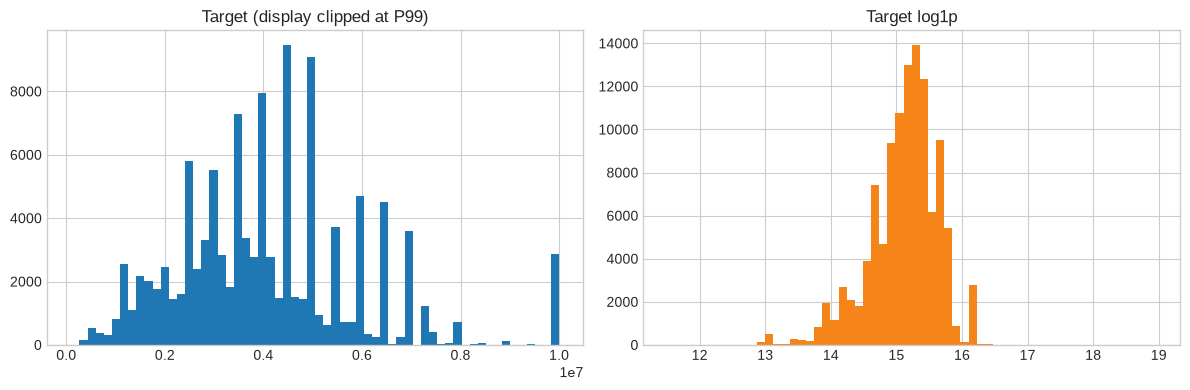

In [ ]:
prepared=engineer_safe_features(silver_df)
TRUSTED_PRICE_STATUSES={'TRUSTED_EXISTING','TRUSTED_REPARSED'}
permissive_masks=build_modeling_eligibility(prepared,policy='PERMISSIVE'); strict_masks=build_modeling_eligibility(prepared,policy='STRICT')
eligibility_funnel_permissive=eligibility_funnel(permissive_masks); eligibility_funnel_strict=eligibility_funnel(strict_masks)
numeric_candidate=permissive_masks.numeric_target_candidate; numeric_trusted=permissive_masks.lineage_trusted
semantic_compatible=permissive_masks.rental_compatible; semantic_reason=pd.Series(np.where(semantic_compatible,'SEMANTICALLY_COMPATIBLE','NOT_RENTAL_COMPATIBLE'),index=prepared.index,dtype='string'); prepared['semantic_eligibility_reason']=semantic_reason
eligible=permissive_masks.final_eligible
model_df=prepared.loc[eligible].copy(); model_df[TARGET]=model_df.price_model_value.astype(float); model_df['group_key']=build_group_key(model_df)
FEATURE_SETS=build_feature_sets(model_df.columns)
for features in FEATURE_SETS.values(): audit_features(features)
before=prepared.loc[numeric_candidate,'price_amount_clean'].astype(float); target=model_df[TARGET].astype(float)
semantic_population_summary=eligibility_funnel_permissive.rename(columns={'Stage':'Population'})
prepared['model_exclusion_reason']=np.select([~numeric_candidate,numeric_candidate&~numeric_trusted,numeric_trusted&~permissive_masks.semantic_target_supported,permissive_masks.semantic_target_supported&~permissive_masks.area_supported,permissive_masks.area_supported&~permissive_masks.rental_compatible],['NO_NUMERIC_CANDIDATE','NUMERIC_TARGET_NOT_TRUSTED','PRICE_SEMANTIC_NOT_SUPPORTED','AREA_NOT_SUPPORTED','NOT_RENTAL_COMPATIBLE'],default='MODEL_ELIGIBLE')
semantic_exclusion_summary=prepared.groupby(['model_exclusion_reason','price_target_trust_status','listing_intent','rental_scope','source_code'],dropna=False).size().rename('Rows').reset_index().sort_values('Rows',ascending=False)
target_distribution_comparison=pd.DataFrame([{'Population':'Before numeric-trust filtering','Rows':len(before),'Min':before.min(),'P01':before.quantile(.01),'P05':before.quantile(.05),'P25':before.quantile(.25),'Median':before.median(),'P75':before.quantile(.75),'P95':before.quantile(.95),'P99':before.quantile(.99),'Max':before.max()},{'Population':'Final eligible trusted target','Rows':len(target),'Min':target.min(),'P01':target.quantile(.01),'P05':target.quantile(.05),'P25':target.quantile(.25),'Median':target.median(),'P75':target.quantile(.75),'P95':target.quantile(.95),'P99':target.quantile(.99),'Max':target.max()}])
semantic_exclusion_examples=prepared.loc[prepared.model_exclusion_reason.ne('MODEL_ELIGIBLE'),['rental_post_id','source_code','title_clean','price_amount_clean','price_model_value','price_target_model_value','price_target_trust_status','price_target_trust_reason','listing_intent','rental_scope','model_exclusion_reason']].groupby('model_exclusion_reason',group_keys=False).head(8)
valid_high_price_examples=prepared.loc[eligible,['rental_post_id','source_code','title_clean',TARGET,'area_value_clean','listing_intent','rental_scope']].nlargest(20,TARGET)
display(pd.Series({'Business target':BUSINESS_TARGET_DEFINITION,'UNKNOWN policy':'PERMISSIVE by default; STRICT evaluated separately','Accepted numeric trust statuses':', '.join(sorted(TRUSTED_PRICE_STATUSES))},name='Policy').to_frame()); display(eligibility_funnel_permissive); display(eligibility_funnel_strict); display(prepared.listing_intent.value_counts(dropna=False).to_frame('Rows')); display(prepared.rental_scope.value_counts(dropna=False).to_frame('Rows')); display(prepared.price_target_trust_status.value_counts(dropna=False).to_frame('Rows')); display(prepared.price_model_suitability.value_counts(dropna=False).to_frame('Rows')); display(prepared.area_model_suitability.value_counts(dropna=False).to_frame('Rows')); display(semantic_exclusion_summary); display(target_distribution_comparison); display(semantic_exclusion_examples); display(Markdown('### Valid high-price rows retained by canonical trust evidence')); display(valid_high_price_examples)
display(pd.DataFrame([{'Feature Set':k,'Features':', '.join(v)} for k,v in FEATURE_SETS.items()]))
display(Markdown('**Leakage exclusions:** identifiers, duplicate group keys, raw/canonical price evidence, `price_per_area`, parser/quality fields, and every target-reconstructive field are excluded.'))
q=target.quantile([.01,.5,.95,.99])
fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].hist(target.clip(upper=q.loc[.99]),bins=60); ax[1].hist(np.log1p(target),bins=60,color='#F58518'); ax[0].set_title('Target (display clipped at P99)'); ax[1].set_title('Target log1p'); plt.tight_layout(); plt.show()

## 03 Group-isolated chronological split using representative group time\n\nSplit isolates duplicate groups to avoid leakage and orders by representative group time.

In [ ]:
split_result=group_aware_split(model_df,model_df.group_key,seed=SEED)
model_df['split']=split_result.labels; assert_group_isolation(model_df.group_key,model_df.split); assert_split_chronology(model_df,model_df.group_key,split_result)
development_df=model_df.loc[model_df.split.ne('TEST')].copy(); test_df=model_df.loc[model_df.split.eq('TEST')].copy()
folds=build_expanding_group_time_folds(development_df,development_df.group_key,n_splits=3)
split_report=model_df.groupby('split').agg(Rows=('rental_post_id','size'),Groups=('group_key','nunique'),Target_Median=(TARGET,'median'),Target_P95=(TARGET,lambda x:x.quantile(.95)),Target_Max=(TARGET,'max'),Min_Time=('latest_observed_at','min'),Max_Time=('latest_observed_at','max')).reindex(['TRAIN','VALIDATION','TEST'])
fold_report=pd.DataFrame([{'Fold':f.fold,'Train Rows':len(f.train_index),'Validation Rows':len(f.validation_index),'Train Groups':f.train_groups,'Validation Groups':f.validation_groups,'Train Start':f.train_start,'Train End':f.train_end,'Validation Start':f.validation_start,'Validation End':f.validation_end} for f in folds])
display(pd.Series({'Strategy':split_result.strategy,'Reason':split_result.reason,'Limitation':'Only ~10 days: short-window future evidence, not long-term generalization'},name='Value').to_frame()); display(split_report); display(fold_report)
TEST_ACCESSED_FOR_SELECTION=False

,Value
Strategy,GROUP_LEVEL_CHRONOLOGICAL_70_15_15
Reason,Whole duplicate groups ordered by representati...
Limitation,"Only ~10 days: short-window future evidence, n..."


,Rows,Groups,Target_Median,Target_P95,Target_Max,Min_Time,Max_Time
split,,,,,,,
TRAIN,77522,76760,4000000.0,7200000.0,170000000.0,2026-09-20 12:48:44,2026-09-28 14:53:25
VALIDATION,18209,16445,3900000.0,6500000.0,60000000.0,2026-09-22 08:11:39,2026-09-29 12:53:17
TEST,16495,16448,3600000.0,6000000.0,35000000.0,2026-09-22 09:01:22,2026-09-30 10:42:53


,Fold,Train Rows,Validation Rows,Train Groups,Validation Groups,Train Start,Train End,Validation Start,Validation End
0,1,51901,14017,51262,13981,2026-09-20 12:48:44,2026-09-26 16:37:33,2026-09-26 16:37:36,2026-09-28 07:44:25
1,2,65918,14073,65243,13981,2026-09-20 12:48:44,2026-09-28 07:44:25,2026-09-28 07:44:27,2026-09-28 16:36:25
2,3,79991,15740,79224,13981,2026-09-20 12:48:44,2026-09-28 16:36:25,2026-09-28 16:36:28,2026-09-29 12:53:17


## 04 Fair preprocessing and model registry

Sklearn models receive fold-fitted one-hot encoding with unknown-category safety. CatBoost uses native strings. LightGBM uses train-defined pandas categories. Every target transform and imputer is learned/applied inside the fold workflow.

In [ ]:
from notebooks.utils.modeling_benchmark import prepare_lightgbm_categories
CATS=['source_code','ward_current','district_text_extracted','province_text_extracted']
MODEL_ORDER=['Linear Regression','Ridge Regression','ElasticNet','Decision Tree Regressor','Random Forest Regressor','Extra Trees Regressor','Gradient Boosting Regressor','HistGradientBoosting Regressor','XGBoost Regressor','LightGBM Regressor','CatBoost Regressor']
BASE_PARAMS={
'Linear Regression':{},'Ridge Regression':{'alpha':100.},'ElasticNet':{'alpha':.001,'l1_ratio':.5},
'Decision Tree Regressor':{'max_depth':12,'min_samples_leaf':30},'Random Forest Regressor':{'n_estimators':80,'max_depth':16,'min_samples_leaf':5,'max_features':.8},
'Extra Trees Regressor':{'n_estimators':80,'max_depth':16,'min_samples_leaf':5,'max_features':.8},'Gradient Boosting Regressor':{'n_estimators':80,'learning_rate':.05,'max_depth':3,'loss':'huber'},
'HistGradientBoosting Regressor':{'max_iter':100,'learning_rate':.07,'max_leaf_nodes':31,'loss':'absolute_error'},
'XGBoost Regressor':{'n_estimators':100,'max_depth':6,'learning_rate':.05,'subsample':.8,'colsample_bytree':.9,'objective':'reg:absoluteerror'},
'LightGBM Regressor':{'n_estimators':120,'num_leaves':31,'learning_rate':.05,'min_child_samples':30,'objective':'mae'},
'CatBoost Regressor':{'iterations':140,'depth':7,'learning_rate':.06,'l2_leaf_reg':5,'loss_function':'MAE'}}

def frames(frame,features,native=False):
 out=frame[features].copy()
 for c in set(features)&set(CATS): out[c]=out[c].astype('string').fillna('__MISSING__') if native else out[c].astype('object').where(out[c].notna(),np.nan)
 return out

def sklearn_pipeline(name,params,features):
 nums=[c for c in features if c not in CATS]; cats=[c for c in features if c in CATS]
 num=[('imputer',SimpleImputer(strategy='median'))]
 if name in ['Linear Regression','Ridge Regression','ElasticNet']: num.append(('scale',StandardScaler()))
 encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1) if name=='HistGradientBoosting Regressor' else OneHotEncoder(handle_unknown='ignore',sparse_output=True)
 pre=ColumnTransformer([('num',Pipeline(num),nums),('cat',Pipeline([('imputer',SimpleImputer(strategy='constant',fill_value='__MISSING__')),('encoder',encoder)]),cats)],sparse_threshold=1.0)
 kw={'random_state':SEED}
 if name=='Linear Regression': model=LinearRegression(**params)
 elif name=='Ridge Regression': model=Ridge(**params)
 elif name=='ElasticNet': model=ElasticNet(max_iter=3000,**kw,**params)
 elif name=='Decision Tree Regressor': model=DecisionTreeRegressor(**kw,**params)
 elif name=='Random Forest Regressor': model=RandomForestRegressor(n_jobs=-1,**kw,**params)
 elif name=='Extra Trees Regressor': model=ExtraTreesRegressor(n_jobs=-1,**kw,**params)
 elif name=='Gradient Boosting Regressor': model=GradientBoostingRegressor(**kw,**params)
 elif name=='HistGradientBoosting Regressor': model=HistGradientBoostingRegressor(**kw,**params)
 elif name=='XGBoost Regressor': model=XGBRegressor(n_jobs=-1,**kw,**params)
 else: raise ValueError(name)
 return Pipeline([('preprocessor',pre),('model',model)])

def fit_predict(name,params,features,fit,score,transform):
 y=transform_target(fit[TARGET],transform); started=time.perf_counter()
 if name=='CatBoost Regressor':
  model=CatBoostRegressor(random_seed=SEED,verbose=False,allow_writing_files=False,thread_count=-1,**params); X=frames(fit,features,True); model.fit(X,y,cat_features=[c for c in features if c in CATS]); fit_s=time.perf_counter()-started; p=time.perf_counter(); pred=model.predict(frames(score,features,True))
 elif name=='LightGBM Regressor':
  cats=[c for c in features if c in CATS]
  X,Z=prepare_lightgbm_categories(fit[features],score[features],cats)
  model=LGBMRegressor(random_state=SEED,n_jobs=-1,verbosity=-1,**params); model.fit(X,y,categorical_feature=cats); fit_s=time.perf_counter()-started; p=time.perf_counter(); pred=model.predict(Z)
 else:
  model=sklearn_pipeline(name,params,features); model.fit(frames(fit,features),y); fit_s=time.perf_counter()-started; p=time.perf_counter(); pred=model.predict(frames(score,features))
 return model,inverse_target(pred,transform),fit_s,time.perf_counter()-p

def baseline_predict(name,fit,score):
 if name=='Global Median': return np.full(len(score),float(fit[TARGET].median()))
 if name=='Hierarchical Location Median': return hierarchical_location_median(fit,score)
 return hierarchical_segment_median(fit,score)

def evaluate_config(name,params,features,feature_set,transform):
 rows=[]
 for f in folds:
  fit=development_df.loc[f.train_index]; score=development_df.loc[f.validation_index]
  if name in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']:
   started=time.perf_counter(); pred=baseline_predict(name,fit,score); fit_s=0.; pred_s=time.perf_counter()-started
  else: _,pred,fit_s,pred_s=fit_predict(name,params,features,fit,score,transform)
  rows.append({'Fold':f.fold,'Model':name,'Target Transform':transform,'Feature Set':feature_set,'Parameters':json.dumps(params,sort_keys=True),**regression_metrics(score[TARGET],pred),'Fit Time':fit_s,'Prediction Time':pred_s,'Train Rows':len(fit),'Validation Rows':len(score),'Train Groups':f.train_groups,'Validation Groups':f.validation_groups,'Group Overlap':0,'Train Start':f.train_start,'Train End':f.train_end,'Validation Start':f.validation_start,'Validation End':f.validation_end,'Target Median':score[TARGET].median(),'Target P95':score[TARGET].quantile(.95),'Target Max':score[TARGET].max()})
 return rows

## 05 F1–F5 development comparison and F4 vs F5 decision

In [ ]:
feature_rows=[]
for feature_set,features in FEATURE_SETS.items(): feature_rows+=evaluate_config('LightGBM Regressor',BASE_PARAMS['LightGBM Regressor'],features,feature_set,'LOG1P')
for feature_set in ['F4 — AREA + SOURCE + LOCATION','F5 — FULL SAFE TABULAR']: feature_rows+=evaluate_config('CatBoost Regressor',BASE_PARAMS['CatBoost Regressor'],FEATURE_SETS[feature_set],feature_set,'LOG1P')
for feature_set in ['F4 — AREA + SOURCE + LOCATION','F5 — FULL SAFE TABULAR']: feature_rows+=evaluate_config('LightGBM Regressor',BASE_PARAMS['LightGBM Regressor'],FEATURE_SETS[feature_set],feature_set,'RAW')
feature_fold_results=pd.DataFrame(feature_rows); feature_summary=summarize_development(feature_fold_results)
f45=feature_summary.loc[feature_summary['Feature Set'].isin(['F4 — AREA + SOURCE + LOCATION','F5 — FULL SAFE TABULAR'])].copy(); display(feature_summary); display(f45)
f45_rows=[]
for (model,transform),g in f45.groupby(['Model','Target Transform']):
 f4=g.loc[g['Feature Set'].str.startswith('F4')].iloc[0]; f5=g.loc[g['Feature Set'].str.startswith('F5')].iloc[0]
 f45_rows.append({'Model':model,'Target Transform':transform,'F4 MAE':f4.MAE_Mean,'F5 MAE':f5.MAE_Mean,'F5 absolute improvement':f4.MAE_Mean-f5.MAE_Mean,'F5 improvement %':(f4.MAE_Mean-f5.MAE_Mean)/f4.MAE_Mean*100,'F5 better':f5.MAE_Mean<f4.MAE_Mean})
f45_decision=pd.DataFrame(f45_rows); consistent=bool(f45_decision['F5 better'].all()); aggregate_gain=f45_decision['F5 absolute improvement'].sum()/f45_decision['F4 MAE'].sum()*100
SELECTED_FEATURE_SET='F5 — FULL SAFE TABULAR' if consistent and aggregate_gain>=1.0 else 'F4 — AREA + SOURCE + LOCATION'; SELECTED_FEATURES=FEATURE_SETS[SELECTED_FEATURE_SET]
display(f45_decision); display(pd.Series({'F5 consistently better':consistent,'Aggregate F5 improvement %':aggregate_gain,'Decision':SELECTED_FEATURE_SET},name='Value').to_frame())

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
5,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.948105e+05,8.879045e+05,24733.061253,650213.898097,0.373321,1.294753
7,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.950408e+05,8.888820e+05,25636.171298,647666.519492,0.373853,1.357092
8,LightGBM Regressor,RAW,F5 — FULL SAFE TABULAR,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.954679e+05,8.885944e+05,18542.294978,653781.914231,0.374234,2.258541
6,LightGBM Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.956563e+05,8.872396e+05,18142.789915,653523.420126,0.373850,1.472062
1,CatBoost Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,9.115125e+05,9.194822e+05,15662.327184,670717.253655,0.376867,1.483415
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,9.275189e+05,9.292246e+05,28093.835850,688724.911687,0.379459,1.337618
4,LightGBM Regressor,LOG1P,F3 — AREA + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,9.507182e+05,9.500982e+05,17566.371381,696376.353504,0.390036,1.048920
3,LightGBM Regressor,LOG1P,F2 — AREA + SOURCE,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.006439e+06,9.872140e+05,35638.220500,792976.098120,0.388704,2.332984
2,LightGBM Regressor,LOG1P,F1 — AREA ONLY,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.043131e+06,1.037187e+06,43885.349921,833487.928050,0.410700,1.036025


,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
5,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,894810.494368,887904.534784,24733.061253,650213.898097,0.373321,1.294753
7,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,895040.800040,888882.040671,25636.171298,647666.519492,0.373853,1.357092
8,LightGBM Regressor,RAW,F5 — FULL SAFE TABULAR,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,895467.935208,888594.390983,18542.294978,653781.914231,0.374234,2.258541
6,LightGBM Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,895656.253018,887239.612812,18142.789915,653523.420126,0.373850,1.472062
1,CatBoost Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,911512.534776,919482.197025,15662.327184,670717.253655,0.376867,1.483415
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,927518.870428,929224.552542,28093.835850,688724.911687,0.379459,1.337618


,Model,Target Transform,F4 MAE,F5 MAE,F5 absolute improvement,F5 improvement %,F5 better
0,CatBoost Regressor,LOG1P,927518.870428,911512.534776,16006.335653,1.725715,True
1,LightGBM Regressor,LOG1P,894810.494368,895656.253018,-845.758649,-0.094518,False
2,LightGBM Regressor,RAW,895040.800040,895467.935208,-427.135169,-0.047722,False


,Value
F5 consistently better,False
Aggregate F5 improvement %,0.542195
Decision,F4 — AREA + SOURCE + LOCATION


## 06 Development-only broad RAW vs LOG1P comparison

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
15,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.948105e+05,8.879045e+05,24733.061253,6.502139e+05,0.373321,2.312486
16,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,8.950408e+05,8.888820e+05,25636.171298,6.476665e+05,0.373853,1.696362
13,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,9.141128e+05,9.023000e+05,21621.659398,6.749222e+05,0.375717,0.473400
14,HistGradientBoosting Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,9.150396e+05,9.052634e+05,19521.763874,6.766035e+05,0.376767,0.468234
20,Random Forest Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,9.163359e+05,9.107460e+05,33832.449059,6.673297e+05,0.377890,2.247818
1,CatBoost Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,9.261994e+05,9.289259e+05,30845.382289,6.834372e+05,0.379393,1.367420
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,9.275189e+05,9.292246e+05,28093.835850,6.887249e+05,0.379459,1.341575
23,XGBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",3,9.288210e+05,9.102692e+05,33527.559056,6.878474e+05,0.377134,2.743456
24,XGBoost Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",3,9.296447e+05,9.119921e+05,35145.010711,6.880628e+05,0.377216,3.409047
3,Decision Tree Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 12, ""min_samples_leaf"": 30}",3,9.495426e+05,9.416703e+05,36501.538250,6.949261e+05,0.387374,0.184857


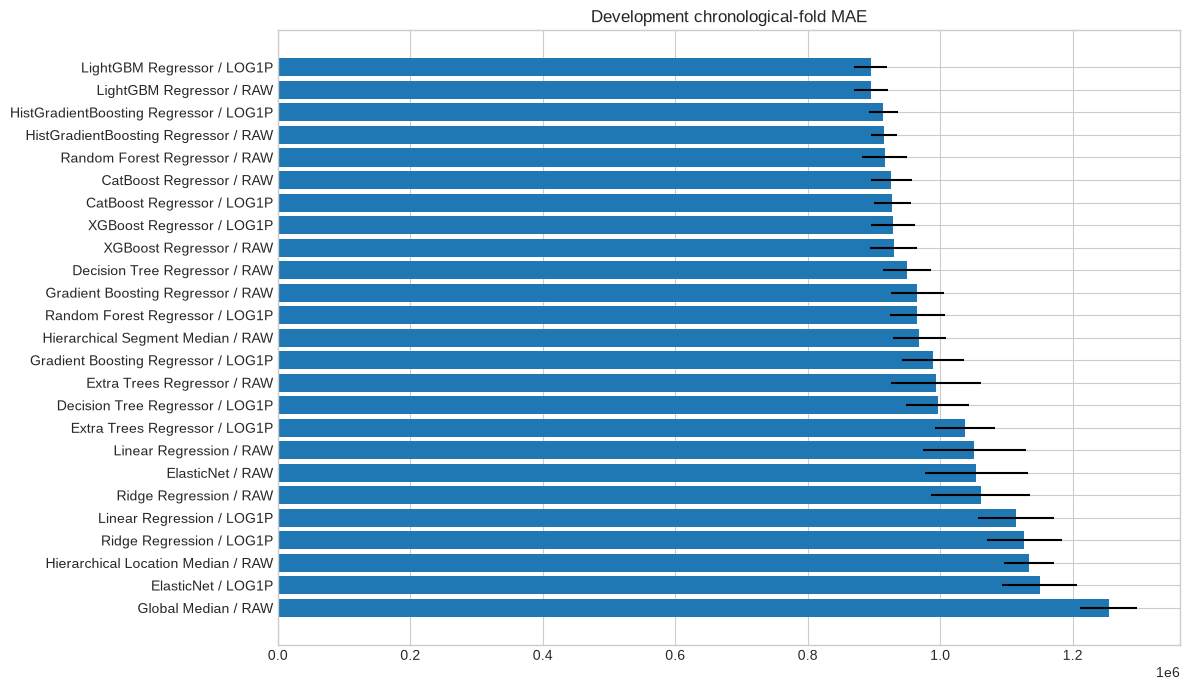

In [ ]:
development_rows=[]
for baseline in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']: development_rows+=evaluate_config(baseline,{},SELECTED_FEATURES,'TRAIN-ONLY BASELINE','RAW')
for name in MODEL_ORDER:
 for transform in ['RAW','LOG1P']: development_rows+=evaluate_config(name,BASE_PARAMS[name],SELECTED_FEATURES,SELECTED_FEATURE_SET,transform)
development_fold_results=pd.DataFrame(development_rows); development_comparison=summarize_development(development_fold_results)
display(development_comparison); assert not TEST_ACCESSED_FOR_SELECTION
fig,ax=plt.subplots(figsize=(12,7)); plot=development_comparison.sort_values('MAE_Mean',ascending=False); ax.barh(plot.Model+' / '+plot['Target Transform'],plot.MAE_Mean,xerr=plot.MAE_Std); ax.set_title('Development chronological-fold MAE'); plt.tight_layout(); plt.show()

## 07 Small bounded tuning and candidate lock

Only the best development configuration per family enters a small bounded refinement. No TEST identities or metrics are accessed.

In [ ]:
best_family=development_comparison.sort_values('MAE_Mean').drop_duplicates('Model'); ml_shortlist=best_family.loc[~best_family.Model.isin(['Global Median','Hierarchical Location Median','Hierarchical Segment Median'])].head(3)
TUNING={
'CatBoost Regressor':[BASE_PARAMS['CatBoost Regressor'],{**BASE_PARAMS['CatBoost Regressor'],'depth':6,'iterations':200}],
'LightGBM Regressor':[BASE_PARAMS['LightGBM Regressor'],{**BASE_PARAMS['LightGBM Regressor'],'num_leaves':63,'n_estimators':180}],
'XGBoost Regressor':[BASE_PARAMS['XGBoost Regressor'],{**BASE_PARAMS['XGBoost Regressor'],'max_depth':5,'n_estimators':160}],
'HistGradientBoosting Regressor':[BASE_PARAMS['HistGradientBoosting Regressor'],{**BASE_PARAMS['HistGradientBoosting Regressor'],'max_iter':160,'max_leaf_nodes':63}],
'Random Forest Regressor':[BASE_PARAMS['Random Forest Regressor'],{**BASE_PARAMS['Random Forest Regressor'],'n_estimators':140}],
'Extra Trees Regressor':[BASE_PARAMS['Extra Trees Regressor'],{**BASE_PARAMS['Extra Trees Regressor'],'n_estimators':140}]}
tuning_rows=[]
for _,row in ml_shortlist.iterrows():
 transform='RAW' if row['Model']=='LightGBM Regressor' else row['Target Transform']
 for params in TUNING.get(row['Model'],[BASE_PARAMS[row['Model']]]): tuning_rows+=evaluate_config(row['Model'],params,SELECTED_FEATURES,SELECTED_FEATURE_SET,transform)
tuning_fold_results=pd.DataFrame(tuning_rows); tuning_summary=summarize_development(tuning_fold_results)
candidate_pool=pd.concat([development_comparison.loc[development_comparison.Model.str.contains('Median')],tuning_summary],ignore_index=True)
COMPLEXITY={'Global Median':0,'Hierarchical Location Median':1,'Hierarchical Segment Median':2,'Linear Regression':3,'Ridge Regression':4,'ElasticNet':5,'Decision Tree Regressor':6,'HistGradientBoosting Regressor':7,'Gradient Boosting Regressor':8,'Random Forest Regressor':9,'Extra Trees Regressor':10,'LightGBM Regressor':11,'XGBoost Regressor':12,'CatBoost Regressor':13}
LOCKED_CANDIDATE=lock_candidate(candidate_pool,COMPLEXITY,tolerance=.01)
LOCKED_MODEL=LOCKED_CANDIDATE.Model; LOCKED_TRANSFORM=LOCKED_CANDIDATE['Target Transform']; LOCKED_PARAMS=json.loads(LOCKED_CANDIDATE.Parameters)
assert not TEST_ACCESSED_FOR_SELECTION
locked_fold_report=tuning_fold_results.loc[(tuning_fold_results.Model.eq(LOCKED_MODEL))&(tuning_fold_results.Parameters.eq(json.dumps(LOCKED_PARAMS,sort_keys=True)))].sort_values('Fold')
assert locked_fold_report['Group Overlap'].eq(0).all()
display(tuning_summary); display(locked_fold_report[['Fold','Train Start','Train End','Validation Start','Validation End','Train Rows','Validation Rows','Train Groups','Validation Groups','Group Overlap','Target Median','Target P95','Target Max','MAE']]); display(LOCKED_CANDIDATE.to_frame('Locked development decision')); display(Markdown(f'### Locked before TEST: **{LOCKED_MODEL} / {LOCKED_TRANSFORM}**'))

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
3,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,890499.762372,881869.933708,24548.393761,645008.048151,0.373230,5.200184
2,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,895040.800040,888882.040671,25636.171298,647666.519492,0.373853,1.631759
1,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,900152.985584,893899.017417,21415.883132,654349.157336,0.374535,1.048573
0,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,914112.766736,902299.988235,21621.659398,674922.202053,0.375717,0.496185
4,Random Forest Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,915999.320331,911131.976328,33812.679884,665789.754371,0.377822,3.992160
5,Random Forest Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,916335.894534,910746.036409,33832.449059,667329.745670,0.377890,2.519271


,Fold,Train Start,Train End,Validation Start,Validation End,Train Rows,Validation Rows,Train Groups,Validation Groups,Group Overlap,Target Median,Target P95,Target Max,MAE
3,1,2026-09-20 12:48:44,2026-09-26 16:37:33,2026-09-26 16:37:36,2026-09-28 07:44:25,51901,14017,51262,13981,0,3900000.0,6500000.0,30000000.0,871431.602073
4,2,2026-09-20 12:48:44,2026-09-28 07:44:25,2026-09-28 07:44:27,2026-09-28 16:36:25,65918,14073,65243,13981,0,3500000.0,6000000.0,25500000.0,881869.933708
5,3,2026-09-20 12:48:44,2026-09-28 16:36:25,2026-09-28 16:36:28,2026-09-29 12:53:17,79991,15740,79224,13981,0,3900000.0,6500000.0,60000000.0,918197.751334


,Locked development decision
Model,LightGBM Regressor
Target Transform,RAW
Feature Set,F4 — AREA + SOURCE + LOCATION
Parameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3..."
Folds,3
MAE_Mean,890499.762372
MAE_Median,881869.933708
MAE_Std,24548.393761
MedianAE_Mean,645008.048151
RMSLE_Mean,0.37323


### Locked before TEST: **LightGBM Regressor / RAW**

## 08 Source ablation and leave-one-source-out diagnostics (development only)

In [ ]:
ablation_rows=[]
NO_SOURCE_FEATURES=[f for f in SELECTED_FEATURES if f!='source_code']
for label,features in [('Without source_code',NO_SOURCE_FEATURES),('With source_code',SELECTED_FEATURES)]: ablation_rows+=evaluate_config(LOCKED_MODEL,LOCKED_PARAMS,features,label,LOCKED_TRANSFORM)
source_ablation=summarize_development(pd.DataFrame(ablation_rows)); without=source_ablation.loc[source_ablation['Feature Set'].eq('Without source_code')].iloc[0]; with_source=source_ablation.loc[source_ablation['Feature Set'].eq('With source_code')].iloc[0]
SOURCE_ABLATION_ABSOLUTE=without.MAE_Mean-with_source.MAE_Mean; SOURCE_ABLATION_PERCENT=SOURCE_ABLATION_ABSOLUTE/with_source.MAE_Mean*100
display(source_ablation); display(pd.Series({'Absolute MAE degradation':SOURCE_ABLATION_ABSOLUTE,'MAE degradation %':SOURCE_ABLATION_PERCENT},name='Value').to_frame())
loso=[]
for source in sorted(development_df.source_code.dropna().unique()):
 train=development_df.loc[development_df.source_code.ne(source)]; score=development_df.loc[development_df.source_code.eq(source)]
 if len(score)<100: continue
 if LOCKED_MODEL in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']: pred=baseline_predict(LOCKED_MODEL,train,score)
 else: _,pred,_,_=fit_predict(LOCKED_MODEL,LOCKED_PARAMS,SELECTED_FEATURES,train,score,LOCKED_TRANSFORM)
 base=baseline_predict('Global Median',train,score); metrics=regression_metrics(score[TARGET],pred)
 loso.append({'Held-out Source':source,'Rows':len(score),'Target Median':score[TARGET].median(),'Target P95':score[TARGET].quantile(.95),'Target Max':score[TARGET].max(),**metrics,'Global Median MAE':regression_metrics(score[TARGET],base)['MAE'],'Baseline Beats Locked':regression_metrics(score[TARGET],base)['MAE']<metrics['MAE']})
leave_one_source_out=pd.DataFrame(loso).sort_values('MAE'); display(leave_one_source_out)

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
0,LightGBM Regressor,RAW,With source_code,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,890499.762372,881869.933708,24548.393761,645008.048151,0.373230,2.190393
1,LightGBM Regressor,RAW,Without source_code,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,950621.301213,950018.680766,18307.718958,695569.290985,0.390915,3.833885


,Value
Absolute MAE degradation,60121.538842
MAE degradation %,6.751438


,Held-out Source,Rows,Target Median,Target P95,Target Max,MAE,Median AE,RMSE,RMSLE,R²,Negative Predictions,Global Median MAE,Baseline Beats Locked
5,phongtro123,54966,3500000.0,6000000.0,50000000.0,9.708701e+05,7.213647e+05,1.362119e+06,0.470857,0.141437,0,1.644261e+06,False
0,cafeland,7587,4000000.0,7000000.0,28000000.0,1.058506e+06,8.078613e+05,1.449096e+06,0.379304,0.114605,0,1.165529e+06,False
3,nhatot,2476,3700000.0,6500000.0,170000000.0,1.128494e+06,8.197277e+05,3.638497e+06,0.443502,0.013219,0,1.226660e+06,False
4,nhatrovn,694,4500000.0,7500000.0,9000000.0,1.446509e+06,1.186884e+06,1.802333e+06,0.407621,-0.401138,0,1.296052e+06,True
2,mogi,2623,3800000.0,7000000.0,60000000.0,1.541028e+06,1.066683e+06,2.549751e+06,0.624058,-0.026946,0,1.534101e+06,True
1,chothuephongtro,27385,5000000.0,10000000.0,23000000.0,2.050294e+06,1.584875e+06,2.640224e+06,0.589563,-0.284728,0,2.377431e+06,False


## 08b UNKNOWN sensitivity — PERMISSIVE vs STRICT (development only)

In [ ]:
def evaluate_sensitivity_population(policy):
 masks=build_modeling_eligibility(prepared,policy=policy)
 population=prepared.loc[masks.final_eligible].copy(); population[TARGET]=population.price_model_value.astype(float); population['group_key']=build_group_key(population)
 population_split=group_aware_split(population,population.group_key,seed=SEED); population['split']=population_split.labels
 development=population.loc[population['split'].ne('TEST')].copy(); population_folds=build_expanding_group_time_folds(development,development.group_key,n_splits=3)
 rows=[]
 for fold in population_folds:
  fit=development.loc[fold.train_index]; score=development.loc[fold.validation_index]
  configurations=[('Hierarchical Segment Median','RAW',{}),(LOCKED_MODEL,LOCKED_TRANSFORM,LOCKED_PARAMS)]
  for name,transform,params in configurations:
   if name=='Hierarchical Segment Median': pred=hierarchical_segment_median(fit,score)
   else: _,pred,_,_=fit_predict(name,params,SELECTED_FEATURES,fit,score,transform)
   metrics=regression_metrics(score[TARGET],pred); threshold=fit[TARGET].quantile(.99); squared=(score[TARGET].to_numpy(float)-pred)**2; extreme=score[TARGET].to_numpy(float)>threshold
   rows.append({'Policy':policy,'Population Rows':len(population),'Development Rows':len(development),'Fold':fold.fold,'Train Rows':len(fit),'Validation Rows':len(score),'Model':name,'Target Transform':transform,**metrics,'Extreme Tail Squared Error %':float(squared[extreme].sum()/squared.sum()*100) if squared.sum() else 0.0})
 stats={'Policy':policy,'Population Rows':len(population),'Development Rows':len(development),'Target Median':population[TARGET].median(),'Target P95':population[TARGET].quantile(.95),'Target P99':population[TARGET].quantile(.99),'Area Median':population.area_value_clean.median(),'Area P95':population.area_value_clean.quantile(.95),'Area P99':population.area_value_clean.quantile(.99),'UNKNOWN Rows':int(population.listing_intent.eq('UNKNOWN').sum())}
 return rows,stats

sensitivity_rows=[]; sensitivity_populations=[]; sensitivity_source_rows=[]
for policy in ['PERMISSIVE','STRICT']:
 rows,stats=evaluate_sensitivity_population(policy); sensitivity_rows.extend(rows); sensitivity_populations.append(stats)
 m=build_modeling_eligibility(prepared,policy=policy); sub=prepared.loc[m.final_eligible]; counts=sub.source_code.value_counts(); pcts=sub.source_code.value_counts(normalize=True)*100
 for src in counts.index: sensitivity_source_rows.append({'Policy':policy,'Source':src,'Rows':int(counts[src]),'Share %':round(float(pcts[src]),2)})
unknown_sensitivity_sources=pd.DataFrame(sensitivity_source_rows)
unknown_sensitivity_fold_results=pd.DataFrame(sensitivity_rows)
unknown_sensitivity_summary=unknown_sensitivity_fold_results.groupby(['Policy','Population Rows','Development Rows','Model','Target Transform'],as_index=False).agg(Folds=('Fold','nunique'),MAE=('MAE','mean'),MAE_Std=('MAE','std'),MedianAE=('Median AE','mean'),RMSE=('RMSE','mean'),RMSLE=('RMSLE','mean'),R2=('R²','mean'),Tail_Squared_Error_Pct=('Extreme Tail Squared Error %','mean'))
baseline_mae=unknown_sensitivity_summary.loc[unknown_sensitivity_summary.Model.eq('Hierarchical Segment Median'),['Policy','MAE']].rename(columns={'MAE':'Baseline MAE'})
unknown_sensitivity_summary=unknown_sensitivity_summary.merge(baseline_mae,on='Policy',how='left'); unknown_sensitivity_summary['Baseline Improvement %']=(unknown_sensitivity_summary['Baseline MAE']-unknown_sensitivity_summary.MAE)/unknown_sensitivity_summary['Baseline MAE']*100
unknown_sensitivity_population=pd.DataFrame(sensitivity_populations)
display(unknown_sensitivity_population); display(unknown_sensitivity_sources); display(unknown_sensitivity_summary); assert not TEST_ACCESSED_FOR_SELECTION

,Policy,Population Rows,Development Rows,Target Median,Target P95,Target P99,Area Median,Area P95,Area P99,UNKNOWN Rows
0,PERMISSIVE,112226,95731,4000000.0,7000000.0,10000000.0,28.0,50.0,150.0,32903
1,STRICT,79323,67748,4000000.0,7200000.0,10000000.0,28.0,50.0,130.0,0


,Policy,Source,Rows,Share %
0,PERMISSIVE,phongtro123,69138,61.61
1,PERMISSIVE,chothuephongtro,27395,24.41
2,PERMISSIVE,cafeland,9354,8.33
3,PERMISSIVE,mogi,2987,2.66
4,PERMISSIVE,nhatot,2579,2.30
5,PERMISSIVE,nhatrovn,773,0.69
6,STRICT,phongtro123,46746,58.93
7,STRICT,chothuephongtro,21397,26.97
8,STRICT,cafeland,9347,11.78
9,STRICT,mogi,1599,2.02


,Policy,Population Rows,Development Rows,Model,Target Transform,Folds,MAE,MAE_Std,MedianAE,RMSE,RMSLE,R2,Tail_Squared_Error_Pct,Baseline MAE,Baseline Improvement %
0,PERMISSIVE,112226,95731,Hierarchical Segment Median,RAW,3,968578.016787,39574.185806,700000.000000,1.387454e+06,0.397502,0.206064,12.033627,968578.016787,0.000000
1,PERMISSIVE,112226,95731,LightGBM Regressor,RAW,3,890499.762372,24548.393761,645008.048151,1.308661e+06,0.373230,0.294763,14.013553,968578.016787,8.061122
2,STRICT,79323,67748,Hierarchical Segment Median,RAW,3,953043.838992,40984.339508,733333.333333,1.387173e+06,0.369310,0.246416,15.903313,953043.838992,0.000000
3,STRICT,79323,67748,LightGBM Regressor,RAW,3,874685.790533,45012.305188,653069.267484,1.300936e+06,0.343520,0.337365,17.816039,953043.838992,8.221872


## 09 FINAL TEST — ONE-TIME EVALUATION

The candidate above is immutable. It is now retrained on all development rows and evaluated once on the sealed future TEST. Baselines are evaluated on the identical TEST rows.

In [ ]:
assert LOCKED_MODEL and not TEST_ACCESSED_FOR_SELECTION
TEST_ACCESSED_FOR_SELECTION=True
test_predictions=pd.DataFrame({'rental_post_id':test_df.rental_post_id.to_numpy(),'group_key':test_df.group_key.to_numpy(),'actual_price':test_df[TARGET].to_numpy(float),'source_code':test_df.source_code.to_numpy(),'ward_current':test_df.ward_current.to_numpy(),'district_text_extracted':test_df.district_text_extracted.to_numpy(),'province_text_extracted':test_df.province_text_extracted.to_numpy(),'area_value_clean':test_df.area_value_clean.to_numpy(),'ward_mapping_status':test_df.ward_mapping_status.to_numpy(),'parse_status':test_df.parse_status.to_numpy(),'title_clean':test_df.title_clean.to_numpy(),'latest_observed_at':test_df.latest_observed_at.to_numpy()})
final_rows=[]; final_model=None
for name in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']:
 pred=baseline_predict(name,development_df,test_df); test_predictions[name]=pred; final_rows.append({'Model':name,'Target Transform':'RAW',**regression_metrics(test_df[TARGET],pred)})
if LOCKED_MODEL in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']:
 locked_pred=baseline_predict(LOCKED_MODEL,development_df,test_df)
else:
 final_model,locked_pred,fit_s,pred_s=fit_predict(LOCKED_MODEL,LOCKED_PARAMS,SELECTED_FEATURES,development_df,test_df,LOCKED_TRANSFORM)
 test_predictions[LOCKED_MODEL]=locked_pred; final_rows.append({'Model':LOCKED_MODEL,'Target Transform':LOCKED_TRANSFORM,**regression_metrics(test_df[TARGET],locked_pred),'Fit Time':fit_s,'Prediction Time':pred_s})
final_test=pd.DataFrame(final_rows).drop_duplicates('Model').sort_values('MAE'); display(final_test)
assert len(test_predictions)==len(test_df)==test_predictions.rental_post_id.nunique()

,Model,Target Transform,MAE,Median AE,RMSE,RMSLE,R²,Negative Predictions,Fit Time,Prediction Time
3,LightGBM Regressor,RAW,9.042908e+05,624464.819404,1.333621e+06,0.420989,0.224074,0,3.224813,0.035692
2,Hierarchical Segment Median,RAW,9.681691e+05,700000.000000,1.390149e+06,0.439815,0.156902,0,NaN,NaN
1,Hierarchical Location Median,RAW,1.119072e+06,900000.000000,1.511336e+06,0.481600,0.003500,0,NaN,NaN
0,Global Median,RAW,1.169146e+06,1000000.000000,1.538993e+06,0.488227,-0.033305,0,NaN,NaN


## 10 Tail, segment, prediction-sanity, and largest-error diagnostics

,Model,Region,Count,MAE,RMSE,Squared Error Contribution %
0,Hierarchical Segment Median,Central ≤ dev P95,16247,9.171219e+05,1.245425e+06,79.055705
1,Hierarchical Segment Median,Upper P95–P99,220,3.633955e+06,3.846644e+06,10.212018
2,Hierarchical Segment Median,Extreme > dev P99,28,9.642857e+06,1.105362e+07,10.732277
3,LightGBM Regressor,Central ≤ dev P95,16247,8.539786e+05,1.183054e+06,77.511286
4,LightGBM Regressor,Upper P95–P99,220,3.482810e+06,3.716267e+06,10.356648
5,LightGBM Regressor,Extreme > dev P99,28,9.838179e+06,1.127449e+07,12.132067


,Dimension,Segment,Count,Small Sample (<100),Baseline MAE,Locked MAE,Baseline Beats Locked
13,Area Band,"(25.0, 28.0]",942,False,7.553822e+05,7.036631e+05,False
11,Area Band,"(-inf, 20.0]",5152,False,8.100196e+05,7.116386e+05,False
12,Area Band,"(20.0, 25.0]",4253,False,8.286617e+05,8.045039e+05,False
14,Area Band,"(28.0, 30.0]",2926,False,9.755793e+05,9.520850e+05,False
15,Area Band,"(30.0, 35.0]",1384,False,1.184371e+06,1.135290e+06,False
16,Area Band,"(35.0, inf]",1838,False,1.668740e+06,1.528002e+06,False
17,Location Resolution,DISTRICT_ONLY,2219,False,1.027850e+06,8.785908e+05,False
19,Location Resolution,WARD_RESOLVED,11888,False,9.348292e+05,8.804044e+05,False
18,Location Resolution,UNRESOLVED,2388,False,1.078685e+06,1.047084e+06,False
1,Price Band,Band 2,3425,False,7.347474e+05,6.603419e+05,False


,Model,Pred Min,Pred Median,Pred P95,Pred P99,Pred Max,Actual Min,Actual Max,Negative,Zero,Outside 100k–100m
0,Hierarchical Segment Median,750000.000000,3.600000e+06,5.150000e+06,5.800000e+06,1.000000e+07,250000.0,35000000.0,0,0,0
1,LightGBM Regressor,711361.575908,3.770640e+06,5.284349e+06,5.755453e+06,6.974426e+06,250000.0,35000000.0,0,0,0


,rental_post_id,actual_price,predicted_price,absolute_error,source_code,area_value_clean,ward_current,district_text_extracted,title_clean
7373,114400,35000000.0,3.463504e+06,3.153650e+07,phongtro123,40.0,NaN,Thành phố Thủ Đức,"CHO THUE NHA CAP 4 GAN DAI HOC NGAN HANG, CAO ..."
333,77546,30000000.0,4.817910e+06,2.518209e+07,cafeland,100.0,Phường Bình Lợi Trung,Quận Bình Thạnh,Phòng trọ: CHO THUÊ NHÀ ( 5x20m) 30triệu Đường...
14761,228615,15000000.0,2.898008e+06,1.210199e+07,phongtro123,100.0,Phường Xóm Chiếu,NaN,Cho thuê nguyên tầng 1 ( có 3 phòng ) mặt tiền...
382,77599,18000000.0,6.576353e+06,1.142365e+07,cafeland,60.0,Phường Bình Lợi Trung,Quận Bình Thạnh,Phòng trọ: CHO THUÊ NHÀ (4x15m) giá 18 triệu Đ...
16125,234178,15000000.0,3.612666e+06,1.138733e+07,phongtro123,60.0,NaN,NaN,"Cho thuê nhà lầu 2,3 + sân thượng 0931151510 T..."
14756,228610,14000000.0,3.812280e+06,1.018772e+07,phongtro123,88.0,Phường Phú Thọ Hòa,NaN,Căn hộ full nội thất Quận Tân Phú 88m² 2PN
6059,110216,12500000.0,2.666921e+06,9.833079e+06,phongtro123,1000.0,NaN,NaN,2PN TRUNG TÂM QUẬN BT(trống sẵn)
12561,222399,12000000.0,2.459394e+06,9.540606e+06,phongtro123,100.0,NaN,NaN,"Penthouse Q.Tân Bình, Phạm Văn Bạch, 1 bếp, 3 ..."
12616,224133,12000000.0,2.459394e+06,9.540606e+06,phongtro123,100.0,NaN,NaN,"PENTHOUSE VIP Q TÂN BÌNH, PHẠM VĂN BẠCH GỒM 3 ..."
12677,224197,12000000.0,2.459394e+06,9.540606e+06,phongtro123,100.0,NaN,NaN,"PENTHOUSE VIP Phạm Văn Bạch, Quận Tân Bình"


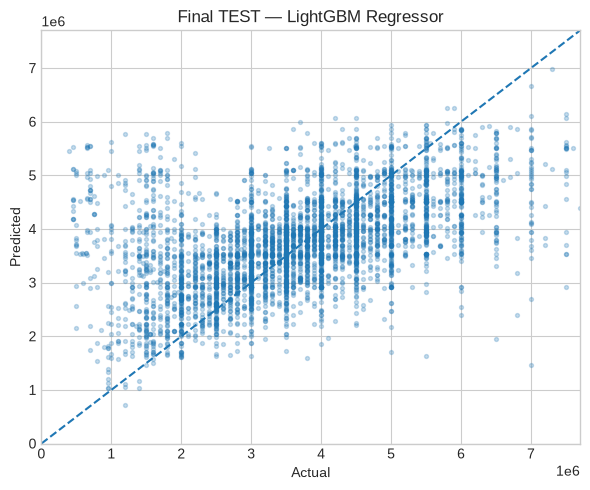

In [ ]:
baseline_name='Hierarchical Segment Median'; names=list(dict.fromkeys([baseline_name,LOCKED_MODEL])); dev_p95=development_df[TARGET].quantile(.95); dev_p99=development_df[TARGET].quantile(.99)
diagnostics=[]
for name in names:
 pred=test_predictions[name]; actual=test_predictions.actual_price; ae=(actual-pred).abs(); se=(actual-pred)**2
 regions=[('Central ≤ dev P95',actual<=dev_p95)]
 if dev_p99>dev_p95: regions.append(('Upper P95–P99',(actual>dev_p95)&(actual<=dev_p99)))
 regions.append(('Extreme > dev P99',actual>dev_p99))
 for region,mask in regions:
  diagnostics.append({'Model':name,'Region':region,'Count':int(mask.sum()),'MAE':ae[mask].mean(),'RMSE':np.sqrt(se[mask].mean()),'Squared Error Contribution %':se[mask].sum()/se.sum()*100})
tail_diagnostics=pd.DataFrame(diagnostics); display(tail_diagnostics)
price_band,price_edges=unique_price_bands(development_df[TARGET],test_predictions.actual_price); _,_,area_edges=add_train_only_area_band(development_df,test_df); area_band=pd.cut(test_predictions.area_value_clean,area_edges,include_lowest=True); location_resolution=np.where(test_predictions.ward_current.notna(),'WARD_RESOLVED',np.where(test_predictions.district_text_extracted.notna(),'DISTRICT_ONLY','UNRESOLVED'))
segments=[]
segment_dimensions={'Price Band':price_band,'Source':test_predictions.source_code,'Area Band':area_band,'Location Resolution':location_resolution}
for dimension,values in segment_dimensions.items():
 for segment,idx in pd.Series(values,index=test_predictions.index).groupby(values,dropna=False,observed=False).groups.items():
  small=len(idx)<100
  base=(test_predictions.loc[idx,'actual_price']-test_predictions.loc[idx,baseline_name]).abs().mean(); ml=(test_predictions.loc[idx,'actual_price']-test_predictions.loc[idx,LOCKED_MODEL]).abs().mean()
  segments.append({'Dimension':dimension,'Segment':str(segment),'Count':len(idx),'Small Sample (<100)':small,'Baseline MAE':base,'Locked MAE':ml,'Baseline Beats Locked':base<ml})
segment_diagnostics=pd.DataFrame(segments); display(segment_diagnostics.sort_values(['Dimension','Locked MAE']))
plausible_min,plausible_max=100_000,100_000_000
sanity=pd.DataFrame([{'Model':n,'Pred Min':test_predictions[n].min(),'Pred Median':test_predictions[n].median(),'Pred P95':test_predictions[n].quantile(.95),'Pred P99':test_predictions[n].quantile(.99),'Pred Max':test_predictions[n].max(),'Actual Min':test_predictions.actual_price.min(),'Actual Max':test_predictions.actual_price.max(),'Negative':int((test_predictions[n]<0).sum()),'Zero':int((test_predictions[n]==0).sum()),'Outside 100k–100m':int(((test_predictions[n]<plausible_min)|(test_predictions[n]>plausible_max)).sum())} for n in names]); display(sanity)
largest=test_predictions.assign(predicted_price=test_predictions[LOCKED_MODEL],absolute_error=(test_predictions.actual_price-test_predictions[LOCKED_MODEL]).abs()).nlargest(25,'absolute_error'); display(largest[['rental_post_id','actual_price','predicted_price','absolute_error','source_code','area_value_clean','ward_current','district_text_extracted','title_clean']])
fig,ax=plt.subplots(figsize=(6,5)); sample=test_predictions.sample(min(5000,len(test_predictions)),random_state=SEED); limit=test_predictions.actual_price.quantile(.99); ax.scatter(sample.actual_price,sample[LOCKED_MODEL],s=8,alpha=.25); ax.plot([0,limit],[0,limit],'--'); ax.set(xlim=(0,limit),ylim=(0,limit),xlabel='Actual',ylabel='Predicted',title=f'Final TEST — {LOCKED_MODEL}'); plt.tight_layout(); plt.show()

## 11 Locked-model feature importance and final verdict

,Feature,Gain,Split Count,Gain %
0,area_value_clean,220596.731864,4909,35.027267
1,source_code,200770.991180,1405,31.879253
2,ward_current,143591.004413,3075,22.799977
3,district_text_extracted,64827.015871,1771,10.293503


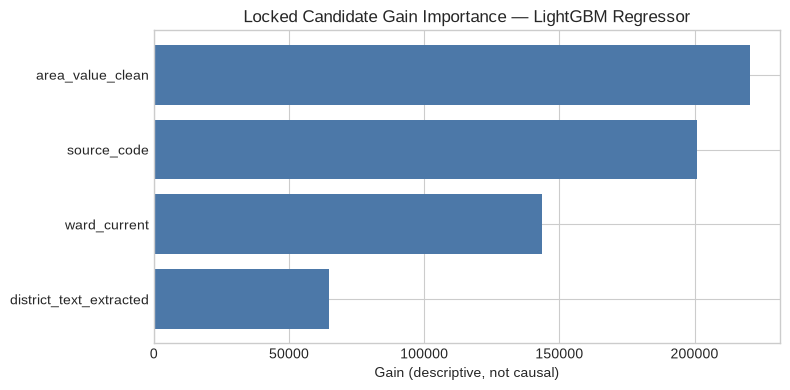

,Criterion,Current Runtime Result
0,Locked candidate,LightGBM Regressor
1,Target transform,RAW
2,Feature set,F4 — AREA + SOURCE + LOCATION
3,TEST MAE,904290.829836
4,TEST MedianAE,624464.819404
5,TEST RMSE,1333621.373128
6,TEST RMSLE,0.420989
7,TEST R²,0.224074
8,Improvement vs Global Median %,22.653712
9,Improvement vs Location Median %,19.192821


In [ ]:
if LOCKED_MODEL=='LightGBM Regressor':
 feature_importance=lightgbm_gain_importance(final_model,SELECTED_FEATURES)
else:
 feature_importance=pd.DataFrame({'Feature':SELECTED_FEATURES,'Gain':np.nan,'Split Count':np.nan,'Gain %':np.nan})
display(feature_importance)
if feature_importance.Gain.notna().any():
 plot=feature_importance.sort_values('Gain'); fig,ax=plt.subplots(figsize=(8,4)); ax.barh(plot.Feature,plot.Gain,color='#4C78A8'); ax.set(title=f'Locked Candidate Gain Importance — {LOCKED_MODEL}',xlabel='Gain (descriptive, not causal)'); plt.tight_layout(); plt.show()
final_locked=final_test.loc[final_test.Model.eq(LOCKED_MODEL)].iloc[0]
baseline_metrics={name:final_test.loc[final_test.Model.eq(name)].iloc[0] for name in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']}
locked_dev=candidate_pool.loc[(candidate_pool.Model.eq(LOCKED_MODEL))&(candidate_pool.Parameters.eq(json.dumps(LOCKED_PARAMS,sort_keys=True)))].sort_values('MAE_Mean').iloc[0]
tail_locked=tail_diagnostics.loc[tail_diagnostics.Model.eq(LOCKED_MODEL)]; extreme=tail_locked.loc[tail_locked.Region.str.startswith('Extreme')].iloc[0]; central=tail_locked.loc[tail_locked.Region.str.startswith('Central')].iloc[0]
readiness='experimental/prototype-ready; not production-ready' if (locked_dev.MAE_Std/locked_dev.MAE_Mean>.15 or (model_df.latest_observed_at.max()-model_df.latest_observed_at.min()).days<30 or extreme['Squared Error Contribution %']>50) else 'production-candidate pending operational validation'
verdict=pd.DataFrame([
 ['Locked candidate',LOCKED_MODEL],['Target transform',LOCKED_TRANSFORM],['Feature set',SELECTED_FEATURE_SET],['TEST MAE',final_locked.MAE],['TEST MedianAE',final_locked['Median AE']],['TEST RMSE',final_locked.RMSE],['TEST RMSLE',final_locked.RMSLE],['TEST R²',final_locked['R²']],
 ['Improvement vs Global Median %',(baseline_metrics['Global Median'].MAE-final_locked.MAE)/baseline_metrics['Global Median'].MAE*100],['Improvement vs Location Median %',(baseline_metrics['Hierarchical Location Median'].MAE-final_locked.MAE)/baseline_metrics['Hierarchical Location Median'].MAE*100],['Improvement vs Strong Segment Median %',(baseline_metrics['Hierarchical Segment Median'].MAE-final_locked.MAE)/baseline_metrics['Hierarchical Segment Median'].MAE*100],
 ['Development MAE mean',locked_dev.MAE_Mean],['Development MAE median',locked_dev.MAE_Median],['Development MAE std',locked_dev.MAE_Std],['Source ablation degradation %',SOURCE_ABLATION_PERCENT],['Extreme-tail squared error share %',extreme['Squared Error Contribution %']],['Central-population MAE',central.MAE],['Readiness',readiness],['Limitation','~10-day short-horizon temporal evidence only']
 ],columns=['Criterion','Current Runtime Result']); display(verdict)

## 12 Persist auditable benchmark evidence

In [ ]:
ARTIFACT_DIR=PROJECT_ROOT/'data'/'modeling'/'roombeacon_price_benchmark_v3'; ARTIFACT_DIR.mkdir(parents=True,exist_ok=True)
tables={'eligibility_funnel_permissive.csv':eligibility_funnel_permissive,'eligibility_funnel_strict.csv':eligibility_funnel_strict,'semantic_population_summary.csv':semantic_population_summary,'semantic_exclusion_summary.csv':semantic_exclusion_summary,'semantic_exclusion_examples.csv':semantic_exclusion_examples,'target_distribution_comparison.csv':target_distribution_comparison,'valid_high_price_examples.csv':valid_high_price_examples,'development_fold_results.csv':development_fold_results,'development_comparison.csv':development_comparison,'feature_fold_results.csv':feature_fold_results,'feature_summary.csv':feature_summary,'f4_f5_decision.csv':f45_decision,'tuning_fold_results.csv':tuning_fold_results,'tuning_summary.csv':tuning_summary,'source_ablation.csv':source_ablation,'leave_one_source_out.csv':leave_one_source_out,'unknown_sensitivity_population.csv':unknown_sensitivity_population,'unknown_sensitivity_sources.csv':unknown_sensitivity_sources,'unknown_sensitivity_fold_results.csv':unknown_sensitivity_fold_results,'unknown_sensitivity_summary.csv':unknown_sensitivity_summary,'final_test.csv':final_test,'tail_diagnostics.csv':tail_diagnostics,'segment_diagnostics.csv':segment_diagnostics,'prediction_sanity.csv':sanity,'feature_importance.csv':feature_importance,'final_verdict.csv':verdict}
for filename,table in tables.items(): table.to_csv(ARTIFACT_DIR/filename,index=False)
with duckdb.connect(':memory:') as con: con.register('_pred',test_predictions); con.execute('copy _pred to ? (format parquet)',[str(ARTIFACT_DIR/'test_predictions.parquet')])
generated_at=datetime.now(timezone.utc).astimezone().isoformat()
metadata={'benchmark':'roombeacon_price_benchmark_v3','generated_at':generated_at,'versions':versions,'hardware':{'platform':platform.platform(),'processor':platform.processor(),'cpu_count':__import__('os').cpu_count()},'seed':SEED,'silver_path':str(SILVER_PATH),'silver_sha256':file_sha256(SILVER_PATH),'silver_metadata':silver_metadata,'business_target_definition':BUSINESS_TARGET_DEFINITION,'semantic_eligibility_policy':'PERMISSIVE default keeps unresolved UNKNOWN absent strong conflict; STRICT is development-only sensitivity evidence','numeric_trust_policy':sorted(TRUSTED_PRICE_STATUSES),'price_model_suitability_policy':['SUPPORTED'],'area_model_suitability_policy':['SUPPORTED'],'eligible_rows':len(model_df),'numeric_untrusted_rows':int((numeric_candidate&~numeric_trusted).sum()),'intent_distribution':prepared.listing_intent.value_counts(dropna=False).to_dict(),'scope_distribution':prepared.rental_scope.value_counts(dropna=False).to_dict(),'trust_distribution':prepared.price_target_trust_status.value_counts(dropna=False).to_dict(),'price_suitability_distribution':prepared.price_model_suitability.value_counts(dropna=False).to_dict(),'area_suitability_distribution':prepared.area_model_suitability.value_counts(dropna=False).to_dict(),'split_strategy':split_result.strategy,'folds':fold_report.astype(str).to_dict('records'),'selected_feature_set':SELECTED_FEATURE_SET,'feature_names':SELECTED_FEATURES,'locked_candidate':LOCKED_MODEL,'locked_transform':LOCKED_TRANSFORM,'locked_parameters':LOCKED_PARAMS,'categorical_strategy':'LightGBM train-defined pandas categories with explicit __MISSING__/__UNKNOWN__; CatBoost native strings; sklearn fold-fitted unknown-safe encoders','selection_rule':'Development fold MAE mean/median/variability; within 1% prefer lower complexity; then MedianAE/RMSLE/runtime','historical_test_previously_observed':True,'test_used_for_current_selection':False,'readiness':readiness,'limitations':['~10-day temporal window','historical temporal test range has already been observed and is not a fresh unbiased champion-comparison window','group-level chronology uses representative max timestamp and does not claim row-level isolation','source mix is dataset representation, not market share']}
assert LOCKED_MODEL=='LightGBM Regressor' and LOCKED_TRANSFORM=='RAW' and SELECTED_FEATURE_SET=='F4 — AREA + SOURCE + LOCATION'
champion_cats=[c for c in SELECTED_FEATURES if c in CATS]
reference_matrix,_,champion_vocabularies=prepare_lightgbm_categories(development_df[SELECTED_FEATURES],development_df[SELECTED_FEATURES],champion_cats,return_vocabularies=True)
reference_predictions=inverse_target(final_model.predict(reference_matrix),LOCKED_TRANSFORM)
reference_profile=build_reference_profile(development_df,reference_predictions,target_column=TARGET,population_name='DEVELOPMENT',uses_test=False)
training_reference={'population':'DEVELOPMENT','row_count':len(development_df),'group_count':development_df.group_key.nunique(),'min_observed_at':development_df.latest_observed_at.min().isoformat(),'max_observed_at':development_df.latest_observed_at.max().isoformat(),'training_cutoff':development_df.latest_observed_at.max().isoformat(),'evidence_cutoff':silver_df.latest_observed_at.max().isoformat(),'uses_test':False,'silver_sha256':metadata['silver_sha256'],'source_snapshot_id':silver_metadata.get('source_snapshot',{}).get('snapshot_id')}
champion_metadata=persist_champion_artifact(final_model,ARTIFACT_DIR,model_family=LOCKED_MODEL,target_transform=LOCKED_TRANSFORM,feature_set=SELECTED_FEATURE_SET,feature_names=SELECTED_FEATURES,hyperparameters=LOCKED_PARAMS,random_seed=SEED,categorical_vocabularies=champion_vocabularies,training_reference=training_reference,expected_schema={'area_value_clean':'numeric','source_code':'categorical','ward_current':'categorical','district_text_extracted':'categorical'},reference_profile=reference_profile,created_at=generated_at)
metadata['training_reference']=training_reference
metadata['model_version']=champion_metadata['model_id']
metadata['champion']={'model_id':champion_metadata['model_id'],'artifact_path':champion_metadata['artifact_path'],'metadata_path':'champion_metadata.json','reference_profile_path':'champion_reference_profile.json','artifact_sha256':champion_metadata['artifact_sha256']}
(ARTIFACT_DIR/'experiment_metadata.json').write_text(json.dumps(metadata,indent=2,ensure_ascii=False),encoding='utf-8')
display(pd.DataFrame([{'Artifact':p.name,'Bytes':p.stat().st_size} for p in sorted(ARTIFACT_DIR.iterdir())])); display(Markdown('**Benchmark V3 complete. Candidate was locked before the one-time final TEST evaluation.**'))

,Artifact,Bytes
0,champion_metadata.json,5805
1,champion_model.joblib,1022203
2,champion_reference_profile.json,8614
3,development_comparison.csv,6065
4,development_fold_results.csv,30186
5,eligibility_funnel_permissive.csv,453
6,eligibility_funnel_strict.csv,427
7,experiment_metadata.json,11188
8,f4_f5_decision.csv,402
9,feature_fold_results.csv,12268


**Benchmark V3 complete. Candidate was locked before the one-time final TEST evaluation.**